# Waveform Separation for 11-stems
*by Snigdha Mahankali and Mikayla Samonte*

Waveform audio separation is an emerging field, led by models like U-Net and DEMUCS, but have not been widely explored. In this notebook, we aimed to explore the realm of waveform music separation for more than 4 stems, and test the logistics of creating a model that can do waveform separation on more than 4 instruments.


# Setup and Imports
This assumes this file lives in Google Drive Folder, which also holds the Moises Db under the folder `datasets` in the file tree structure:
```
|_______ 11-stem_Waveform_Separation.ipynb
|_______ datasets
| |_____ moisesdb
| | |___ moisesdb
| | | |_ moisesdb_v0.1 <- holds the data
```

In [ ]:
# Connect to google drive
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cse493g1/final'
FOLDERNAME = 'cse493g1/final'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/MyDrive/{}'.format(FOLDERNAME))

Mounted at /content/drive


In [ ]:
# Connect to GPU
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as dset
import torchvision.transforms as T

import numpy as np

USE_GPU = True
dtype = torch.float32 # We will be using float throughout this tutorial.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cuda


In [ ]:
# Import the model demucs
!pip install demucs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 8.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.3/249.3 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 8.4 MB/s eta 0:00:00
  Created wheel for demucs: filename=demucs-4.0.1-py3-none-any.whl size=78388 sha256=32eef13c8e20fc127153371e36d3fe3eef3ab3c7c5a504d3f023cca3b0d5e4c7
  Stored in directory: /root/.cache/pip/wheels/1b/0c/20/a3b3daa1f9b65c8b0445729f94740ec335d0f86f1066c5c414
  Created wheel for julius: filename=julius-0.2.7-

In [ ]:
# import the dataset library
!pip install git+https://github.com/moises-ai/moises-db.git

  Cloning https://github.com/moises-ai/moises-db.git to /tmp/pip-req-build-4xqqcmv3
  Running command git clone --filter=blob:none --quiet https://github.com/moises-ai/moises-db.git /tmp/pip-req-build-4xqqcmv3
  Resolved https://github.com/moises-ai/moises-db.git to commit 1fbc5c784e24c6f0eb826d7ee782b53a5964b9b6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for moises-db: filename=moises_db-0.0.3-py3-none-any.whl size=15695 sha256=b1e341da4eaf01e3c438e40a51aafff4a98966b3b7ac5a50422874f9b4fb53e0
  Stored in directory: /tmp/pip-ephem-wheel-cache-ie25d1q_/wheels/a6/e3/0d/c12feb835619541bce8f3adafdefe4d437b49691370f8a969a
Successfully built moises-db


In [ ]:
# load the dataset into memory
from moisesdb.dataset import MoisesDB

db = MoisesDB(
    data_path='/content/drive/MyDrive/cse493g1/final/datasets/moisesdb/moisesdb',
    sample_rate=44100
)

Loading tracks info from provider moisesdb_v0.1: 100%|██████████| 120/120 [00:18<00:00,  6.38it/s]


# Initialize Dataset

In [ ]:
# Notebook Constants

# how long each dataset sample should be
SEGMENT_SIZE = 44100 * 5 # 5 seconds

# list of instruments (in order of finetuner classification) the model will classify
new_instruments = ['guitar', 'wind', 'percussion', 'piano', 'other_keys', 'other', 'bowed_strings', 'other_plucked']
all_instruments = ["drums", "bass", 'vocals'] + new_instruments

In [ ]:
# Dataset helper methods
def pad_or_crop(x, size):
  """
  Helper method for the Dataset object to pad or crop a waveform to a given size.
  Inputs:
  - x: waveform of shape (2, x)
  - size: size to pad or crop to
  Outputs:
  - x: waveform of shape (2, size)
  """
  if x.shape[1] < size:
    pad = size - x.shape[1]
    return np.pad(x, ((0,0),(0,pad)))
  else:
    return x[:, :size]

In [ ]:
from torch.utils.data import Dataset

class MoisesDataset(Dataset):
    def __init__(self, db, segment_seconds=5):
        self.db = db # stores the Moises Db

    def __len__(self):
        return len(self.db)

    def __getitem__(self, idx):
        # just in case we want to have more samples
        track = self.db[idx % len(self.db)]

        # audio is in the shape (2, filesize)
        audio = track.audio
        genre = track.genre
        song_len = audio.shape[1]

        # get a random section of the song
        if song_len > SEGMENT_SIZE:
            start = np.random.randint(0, song_len - SEGMENT_SIZE)
        else:
            start = 0

        # crop the song and the stems in the same place
        # add padding if needed
        mixture = pad_or_crop(audio[:, start:start+SEGMENT_SIZE], SEGMENT_SIZE)

        # now that we have the cropped stems, in order to have batches across all songs,
        # make the shape (11, 2, filesize)
        target_list = []
        # for each of the 11 instruments
        for inst in all_instruments:
          # if it is in names, use that actual stem
          if inst in track.stems.keys():
            stem = track.stems[inst]
            # crop the stem as needed
            stem = pad_or_crop(stem[:, start:start+SEGMENT_SIZE], SEGMENT_SIZE)
            # add to targets
            target_list.append(stem)
          else:
            # otherwise, add silence in the shape (2, filesize)
            target_list.append(
                np.zeros((2, SEGMENT_SIZE), dtype=np.float32) # Changed to np.zeros
            )
        stems = np.stack(target_list) # stack to the shape (11, 2, filesize)

        return torch.from_numpy(mixture).float(), torch.from_numpy(stems).float(), genre # convert to tensors

In [ ]:
from torch.utils.data import DataLoader, random_split

dataset = MoisesDataset(db)
# dataset size
N = len(dataset)

# Final proportions = 20% TEST, 20% VAL, 60% TRAIN  (from 120 total datapoints)
test_size = int(0.2 * N)
val_size = int(0.2 * N)
train_size = N - test_size - val_size

train_data, val_data, test_data = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducible
)

print("TRAIN:", len(train_data)) # 72
print("VAL:", len(val_data)) # 24
print("TEST:", len(test_data)) # 24

TRAIN: 72
VAL: 24
TEST: 24


In [ ]:
# unpack the model we will finetune
import torch
from demucs import pretrained
from demucs.apply import apply_model
model = pretrained.get_model('htdemucs')

Downloading: "https://dl.fbaipublicfiles.com/demucs/hybrid_transformer/955717e8-8726e21a.th" to /root/.cache/torch/hub/checkpoints/955717e8-8726e21a.th


100%|██████████| 80.2M/80.2M [00:00<00:00, 93.3MB/s]


# Finetuning Helper Functions

In [ ]:
# calculate the difference or distortion between two sounds
def si_sdr(pred, target, eps=1e-8):
  """
  Calculates the SI-SDR between two signals.
  Inputs:
  - pred: prediction of shape (2, filesize)
  - target: target of shape (2, filesize)
  Outputs:
  - the number si-sdr score
  """
  # s = target stem
  # s_hat = pred stem (singular stem)
  # a = dot_product(s, s_hat) / ||s||^2
  # dot_product = np.sum(s * s_hat)
  # where ||s||^2 = np.sum(s^2) (square all values and add it all up)
  numer = torch.sum(pred * target)
  denom = torch.sum(target ** 2) + eps # square all values and add it all up
  alpha = numer / denom

  # to calculate si-sdr, we need ||a * s||^2 / ||s_hat - a*S||^2
  alpha_times_s = alpha * target
  numer1 = torch.sum((alpha_times_s)**2)
  denom1 = torch.sum((pred - alpha_times_s)**2)+ eps
  inner = numer1 / denom1

  # finally we need to do the 10 * log(all that stuff)
  return 10 * torch.log10(inner + eps)

In [ ]:
def si_sdr_batched(pred, target, eps=1e-8):
  """
  Calculates the SI-SDR between two batches of signals
  Inputs:
  - pred: prediction of shape (B, 11, 2, T)
  - target: target of shape (B, 11, 2, T)
  Outputs:
  - si-sdr score of each batch in the shape (B,)
  """
  B, N, C, T = pred.shape

  # merge batch and instrument dims
  pred = pred.reshape(B * N, C, T)
  target = target.reshape(B * N, C, T)

  # zero-mean
  pred = pred - pred.mean(dim=-1, keepdim=True)
  target = target - target.mean(dim=-1, keepdim=True)

  # projection
  dot = torch.sum(pred * target, dim=(1,2), keepdim=True)
  target_energy = torch.sum(target**2, dim=(1,2), keepdim=True) + eps

  # compute si-sdr
  proj = dot * target / target_energy
  noise = pred - proj
  ratio = torch.sum(proj**2, dim=(1,2)) / (torch.sum(noise**2, dim=(1,2)) + eps)
  sdr = 10 * torch.log10(ratio + eps)

  # reshape back
  return sdr.reshape(B, N)

In [ ]:
import matplotlib.pyplot as plt
# plotting methods

def getGraph(scores):
  """
  Plots the SI-SDR score per key in map
  Inputs:
  - scores: the average score per key. Expects the format {"key": score}
  """
  plt.figure(figsize=(12,5))
  plt.bar(range(len(scores)), scores.values(), align='center')
  plt.xticks(range(len(scores)), list(scores.keys()), rotation = 45, ha='right')
  plt.tight_layout()
  plt.show()
import matplotlib.pyplot as plt

def getPlots(accuracy, genre_scores, instrument_scores):
  """
  Print the accuracy, genre scores, and instrument scores in a readable way
  Calculates values to put in graphs, and runs the getGraph methods
  Inputs:
  - accuracy: the accuracy of the model
  - genre_scores: the scores per genre
  - instrument_scores: the scores per instrument
  """
  # plot the baseline genre and instrument accuracy
  print("model accuracy", accuracy)

  instrument_avg = {}
  # calculate the per-instrument average
  for instrument in instrument_scores:
    # calculate the per-instrument accuracy
    instrument_avg[instrument] = instrument_scores[instrument][0] / max(instrument_scores[instrument][1], 1)
  print("instrument scores", instrument_avg)

  getGraph(instrument_avg)

  # calculate the per genre accuracy
  genre_avg = {}
  for genre in genre_scores:
    # calculate the per-genre average
    # genre_scores[genre] = genre_scores[genre][0] / genre_scores[genre][1]
    genre_avg[genre] = genre_scores[genre][0] / genre_scores[genre][1]

  # plot the graphs
  getGraph(genre_avg)

In [ ]:
from tqdm import tqdm
import torch

def train_val(SeparationModel, data_loader, train_optimizer, plots, epoch, epochs, device='cuda'):
  """
  Train or Evaluate the finetuner

  Inputs:
  - SeparationModel: the finetuner to train or evaluate
  - data_loader: the data to train or evaluate on
  - train_optimizer: the optimizer to use for training
  - plots: where to add accumulated accuracy, genre, and instrument stats.
  Should be in the form { "train_loss": [], "train_sisdr": [],
  "genre": { "genre": [total_sum, count] }, "instruments": { "instrument": [total_sum, count] }
  - epoch: the current epoch
  - epochs: the total number of epochs
  - device: the device to use for training

  Outputs:
  - total_loss: the total loss
  - total_sisdr: the total si-sdr score
  - updates plots with aggregated stats
  """
  total_loss = 0.0
  total_sisdr = 0.0
  total_num = 0

  # set the model to train or eval based on if a optimizer is passed in
  is_train = train_optimizer is not None
  SeparationModel.train() if is_train else SeparationModel.eval()

  # progress bar
  data_bar = tqdm(data_loader)

  with (torch.enable_grad() if is_train else torch.no_grad()):
    for t, (mix, moises_stems, genre) in enumerate(data_bar):

      mix = mix.to(device, non_blocking=True) # (B,2,T)
      moises_stems = moises_stems.to(device, non_blocking=True) # (B,11,2,T)

      # normalize the mix
      mix = mix / (mix.abs().max(dim=-1, keepdim=True)[0] + 1e-8)

      # forward pass
      pred = SeparationModel(mix) # (B,11,2,T)

      # ----- mixture consistency projection -----
      # compute the mean energy over the audio for each stem in each track
      pred_energy = torch.mean(pred ** 2, dim=(2,3)) # (B,11)
      # normalize to the avoid favoring loud instruments
      proj_weights = torch.sqrt(pred_energy + 1e-8) # (B,11)
      # expand back out to (B, 11, 1, 1)
      proj_weights = proj_weights.view(proj_weights.shape[0], proj_weights.shape[1], 1, 1)

      # add to the prediction to make sure that the predictions add up to the mix
      # so the model is penalized for having noise bleed across stems
      # (mix.unsqueeze(1) - pred.sum(dim=1, keepdim=True) = error in
      # how well the prediction did at reconstructing the mix)
      # then we weight that per stem so we know which stems need to get better
      pred = pred + proj_weights * (
          mix.unsqueeze(1) - pred.sum(dim=1, keepdim=True)
      )

      # get the si-sdr score
      score = si_sdr_batched(pred, moises_stems)  # (B, 11)

      # ----- calculate weighted score based on which stems aren't silent -----

      # see if which stems (from the moises answer) are silent
      moises_stems_energy = torch.mean(moises_stems ** 2, dim=(2,3))

      # prioritize the stems that should have sound
      valid_mask = moises_stems_energy > 1e-6
      # sqrt to make sure loud stems don't dominate classification
      weights = torch.sqrt(moises_stems_energy)
      # get the stems that should have sound
      weights = weights * valid_mask
      # normalize the weights
      weights = weights / (weights.sum(dim=1, keepdim=True) + 1e-8)

      # calculate the weighted score
      # this is the loss for the stems that should have sound
      # (this prevents the model from trying to optimize the noise in silent predictions)
      # since silent stems are handled seperately
      loss_sisdr = -(score * weights).sum(dim=1).mean()

      # clamp only for logging (to prevent large negative scores)
      score = torch.clamp(score, min=-30, max=30)

      # ----- penalize the model for predicting sound when there should be silence -----
      silent_mask = ~valid_mask # get silent mask
      # get all the avg of the stems that should be silent
      # (if there are stems that should be silent)
      if silent_mask.any():
        silence_loss = torch.mean(torch.abs(pred[silent_mask]))
      else:
        silence_loss = torch.tensor(0.0, device=device)

      # ----- add l1 loss to help with early loss -----
      # add l1 term: helps stabilize early si-sdr noise into a
      # useable waveform to optimize
      stem_scale = torch.sqrt(moises_stems_energy + 1e-6).unsqueeze(-1).unsqueeze(-1)
      l1 = torch.mean(torch.abs(pred - moises_stems) / (stem_scale + 1e-6))

      # ----- Calculate the final loss -----
      loss = loss_sisdr + 0.3 * l1 + 2.0 * silence_loss

      # ----- Learn from the final loss -----
      if is_train:
        # learn from the loss
        train_optimizer.zero_grad()
        loss.backward()
        # add gradient clipping
        torch.nn.utils.clip_grad_norm_(SeparationModel.parameters(), 1.0)
        # use optimizer to learn
        train_optimizer.step()

      # use the batch size the add to accumulation stats
      B = mix.size(0)
      total_num += B
      total_loss += loss.item() * B
      # compute the weighted avg for sisdr
      weighted_metric = (score * weights).sum(dim=1).mean()
      total_sisdr += weighted_metric.item() * B

      # if train, add to plots[train_...]
      # add the current avg loss and acc
      if is_train:
        plots["train_loss"].append(loss.item())
        plots["train_sisdr"].append(total_sisdr / total_num)

        if t % 5 == 0:
          # checkpoint = save the weights
          torch.save(SeparationModel.finetuner.state_dict(), "/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth")

      # add to genre
      if genre not in plots["genre"]:
        plots["genre"][genre] = [0,0]
      plots["genre"][genre][0] += total_sisdr / total_num
      plots["genre"][genre][1] += 1

      # add score to instruments (only for instruments that are not silent)
      for i, inst in enumerate(all_instruments):
        # see if for this intrument, there is any valid non-silent stem
        valid = valid_mask[:, i] # (B, 1)
        if valid.any():
            # if there is, take the sum instrument score and add it to instrument score
            plots["instruments"][inst][0] += score[valid, i].sum().item()
            plots["instruments"][inst][1] += valid.sum().item() # all valid tracks

      # update the progress bar
      data_bar.set_description(
        '{} Epoch: [{}/{}] Loss: {:.4f} SI-SDR: {:.2f} dB'.format(
            'Train' if is_train else 'Val',
            epoch,
            epochs,
            total_loss / total_num,
            total_sisdr / total_num
        )
      )

  return total_loss / total_num, total_sisdr / total_num

# Example DEMUCS output

In [ ]:
# Import library to play the pred_stems
from IPython.display import Audio, display

# pick a random mix from the train set
mix, stems, genre = train_data[0]
print("mix aka original audio", mix.shape)
print("stems aka ground truth", stems.shape)
print("genre", genre)

mix.unsqueeze_(0)  # add batch dimension
pred_stems = apply_model(model, mix)  # apply the model to the given mix.

print("Mix object is: ", type(mix))
print(mix.shape) # (batch_size, channels, samples/time)
print("Model object is: ", type(model))
print("pred_Stems object is: ", type(pred_stems))
print(pred_stems.shape)  # (batch_size, stem_count, stero channels, samples/time)

# Play the original audio
print("Original Audio")

# displays audio in a playable format
  # mix[0] = removes batch dimension, leaves [channels, samples] = audio waveform
  # .cpu = audio player can't read gpu tensors so move to cpu
  # .numpy = audio player expects numpy
display(Audio(mix[0].cpu().numpy(), rate=44100))

# Play each stem (currently 4 pred_stems)
demucs_names = ["Drums", "Bass", "Other", "Vocals"] # Demucs stores stem wav files in this order
for i, name in enumerate(demucs_names):
  print(name)
  # grab pred_stems[batch, stem] to play waveform
  display(Audio(pred_stems[0,i].cpu().numpy(), rate=44100))
  # cd quality is 44,100 kHz (kilohertz)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Access the stems straight from the MoisesDB's given stems
# stems has the size (num_stems, 2, segmentsize)
# names has the size (num_stems,)
for i in range(len(stems)):
  print(all_instruments[i])
  # grab stem to play waveform
  # Play each stem
  print("MAX: ", stems[i].abs().max())  # if tensor(0.) = stem is silent
  display(Audio(stems[i], rate=44100))
  # cd quality is 44,100 kHz (kilohertz)

Output hidden; open in https://colab.research.google.com to view.

# Initialize the Finetuner

In [ ]:
# make classes to use in the finetune model
import torch.nn as nn
import torch.nn.functional as F

class Flatten(nn.Module):
    def forward(self, x):
        return nn.flatten(x, start_dim=1)

class Reshape(nn.Module):
    def __init__(self, stems=8):
        super().__init__()
        self.stems = stems

    def forward(self, x):
        B, C, T = x.shape
        return x.view(B, self.stems, 2, T)

In [ ]:
# define the finetuner
class Fine_al_tuner(nn.Module):
  def __init__(self):
    super(Fine_al_tuner, self).__init__()

    # Encoder
    self.demucs = pretrained.get_model('htdemucs')

    # Classifier
    self.finetuner = nn.Sequential(
      # (B, 2, T) → (B, 8, T)
      nn.Conv1d(2, 8, kernel_size=5, padding=2),
      nn.ReLU(),
      # (B, 8, T) → (B, 8, T/4)
      nn.MaxPool1d(4),
      # more feature processing
      nn.Conv1d(8, 16, kernel_size=5, padding=2),
      nn.ReLU(),
      # restore time resolution
      nn.Upsample(scale_factor=4, mode="linear", align_corners=False),
      # output stems
      nn.Conv1d(16, 16, kernel_size=1),
      Reshape(8) # (B, 8, 2, T)
     )

  def forward(self, x):
    # x is in the shape (B, 2, T)
    x = apply_model(self.demucs, x) # get demucs output (B, 4, 2, T)
    # get other
    other = x[:, 2] # (B, 2 T)
    # pass through finetuner
    new_stems = self.finetuner(other) # (B, 8, 2, T)
    # combine original stems to get (B, 11, 2, T)
    og_stems = x[:, [0, 1, 3]] # (B, 3, 2, T)
    return torch.cat((og_stems, new_stems), dim=1) # (B, 11, 2, T)

# Train the Finetuner

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import os

learning_rate = 2e-5
epochs = 1
best_acc = 0.0
plots = { "train_loss": [], "train_sisdr": [],
  "genre": {}, "instruments": {} }
plots["instruments"] = {i:[0,0] for i in all_instruments}

# get dataloaders
small_train_data = Subset(train_data, indices=list(range(0, 72)))
small_train_loader = DataLoader(small_train_data, batch_size=1, shuffle=True, num_workers=0, pin_memory=True)

# initialize the Finetuner
SeparationModel = Fine_al_tuner()
SeparationModel.to(device) # move to gpu
# initialize the optimizer
optimizer = optim.Adam(SeparationModel.parameters(), lr=learning_rate, betas=(0.9, 0.999))

for param in SeparationModel.parameters():
  param.requires_grad = True
# freeze demucs weights
for param in SeparationModel.demucs.parameters():
  param.requires_grad = False

# Ensure the directory for saving weights exists
output_dir = os.path.dirname("/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth")
if output_dir:
    os.makedirs(output_dir, exist_ok=True)

# load in the finetuner's weigths
if os.path.exists("/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth"):
  print("Loading weights from long path")
  SeparationModel.finetuner.load_state_dict(torch.load("/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth"))
else:
  print("No previous weights, starting again")

for epoch in range(1, epochs + 1):
  train_loss, train_sisdr = train_val(SeparationModel, small_train_loader, optimizer, plots, epoch, epochs)
  # save the best accuracy
  if train_sisdr > best_acc:
    best_acc = train_sisdr

print("best train acc", best_acc)
# save the model
torch.save(SeparationModel.finetuner.state_dict(), "/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth")
print("saved model!")

Loading weights from long path


Train Epoch: [1/1] Loss: 5.0924 SI-SDR: 6.00 dB: 100%|██████████| 72/72 [2:10:28<00:00, 108.72s/it]

best train acc 6.000428821477625
saved model!


{'train_loss': [10.276272773742676, 10.36761474609375, 3.3424065113067627, 7.974123477935791, 3.2676498889923096, 8.491171836853027, 5.134105682373047, 6.501688003540039, 4.961808681488037, 10.263315200805664, 9.697504997253418, 3.7986319065093994, 14.912647247314453, 4.094498157501221, 4.704322338104248, 5.265437126159668, 11.405701637268066, 4.387447834014893, 6.127995491027832, -11.621025085449219, 7.552567958831787, 9.294116973876953, 1.813988447189331, 4.26507568359375, 4.904667377471924, 0.6670207381248474, 8.517117500305176, 2.113109588623047, 10.648560523986816, 2.5294315814971924, -4.052692890167236, 9.219770431518555, 6.507569789886475, 6.429545879364014, 7.692723751068115, 2.147106409072876, 6.239212512969971, 4.148970603942871, 2.6921567916870117, 6.493089199066162, 2.0315675735473633, 23.957778930664062, -0.9684402346611023, 9.711063385009766, 4.52102518081665, -0.13242892920970917, 3.6939892768859863, 2.1389594078063965, 6.023428440093994, 4.723743915557861, 0.00330436229

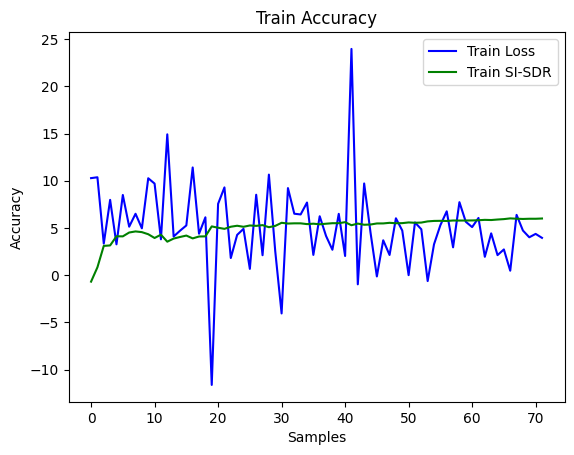

In [ ]:
# plot the training stats
import matplotlib.pyplot as plt
print(plots)
plt.plot(plots["train_loss"], color="blue", label="Train Loss")
plt.plot(plots["train_sisdr"], color="green", label="Train SI-SDR")
plt.xlabel('Samples')
plt.ylabel('Accuracy')
plt.title('Train Accuracy')
plt.legend()
plt.show()


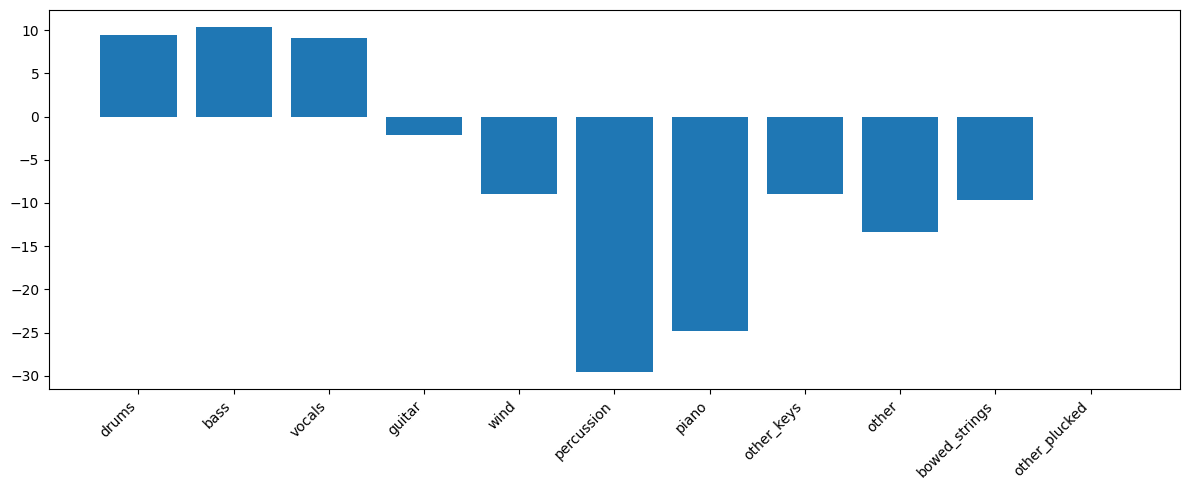

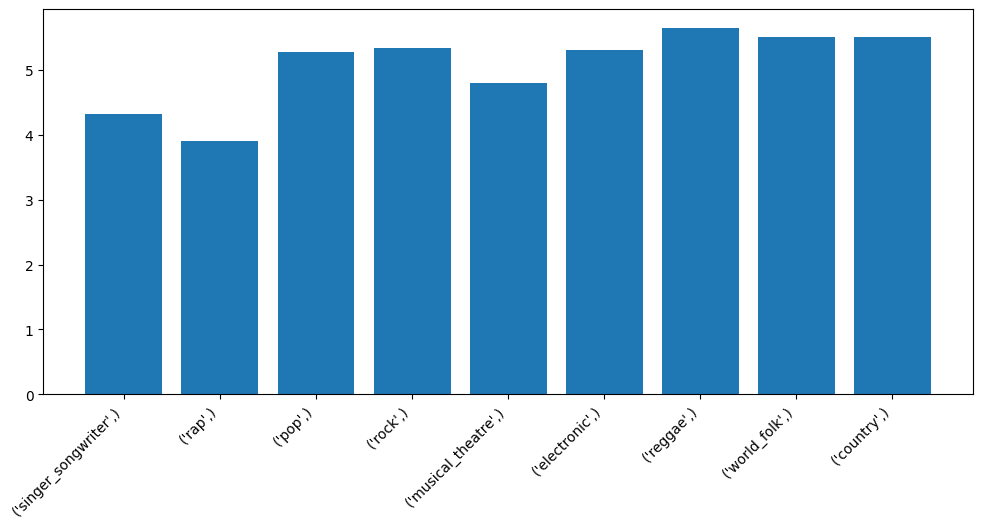

In [ ]:
# format the genre and instrument scores back to averages
for genre in plots["genre"]:
  if type(plots["genre"][genre]) == list:
    plots["genre"][genre] = plots["genre"][genre][0] / plots["genre"][genre][1]

for inst in plots["instruments"]:
  if plots["instruments"][inst][1] == 0:
    plots["instruments"][inst] = 0
  else:
    plots["instruments"][inst] = plots["instruments"][inst][0] / plots["instruments"][inst][1]

# plot the graphs
getGraph(plots["instruments"])
getGraph(plots["genre"])

# What Finetuner sounds like

In [ ]:
# Import library to play the pred_stems
from IPython.display import Audio, display

# get some song
mix = train_data[35][0] # (2,T)
mix.unsqueeze_(0) # (1,2,T)
mix = mix.to(device) # Move the input tensor to the GPU

# get the stems
pred_stems = SeparationModel(mix)

# Play the original audio
print("Original Audio")

# displays audio in a playable format
  # mix[0] = removes batch dimension, leaves [channels, samples] = audio waveform
  # .cpu = audio player can't read gpu tensors so move to cpu
  # .detach = make sure all tensors to cpu
  # .numpy = audio player expects numpy
display(Audio(mix[0].cpu().numpy(), rate=44100))

# Play each stem (currently 4 pred_stems)
for i, name in enumerate(all_instruments):
  print(name)
  # grab pred_stems[batch, stem] to play waveform
  display(Audio(pred_stems[0,i].cpu().detach().numpy(), rate=44100)) # Added .detach()
  # cd quality is 44,100 kHz (kilohertz)

Output hidden; open in https://colab.research.google.com to view.

# Test the model on Val data

Loading weights from long path


Val Epoch: [1/1] Loss: 10.5578 SI-SDR: 1.39 dB: 100%|██████████| 24/24 [51:43<00:00, 129.29s/it]


best_acc 1.3904762988289197


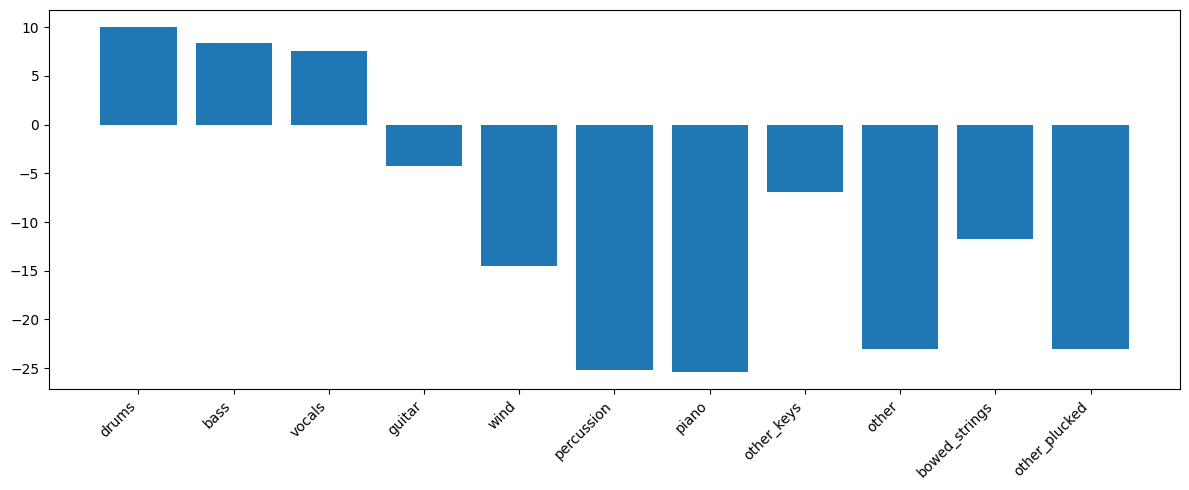

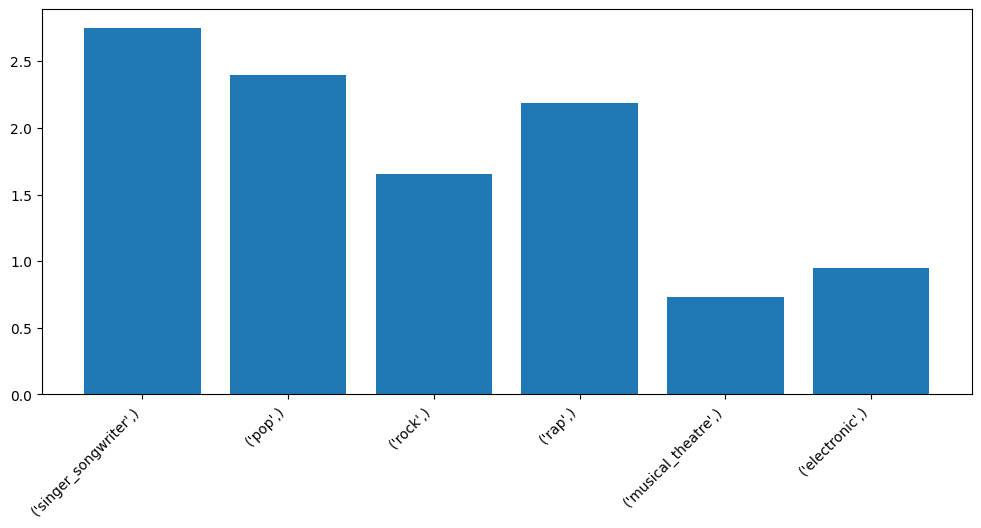

In [ ]:
# test the model ON VAL DATA
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import os # Import the os module

learning_rate = 2e-5
epochs = 1 # Increased epochs
best_acc = 0.0
plots = { "train_loss": [], "train_sisdr": [],
  "genre": {}, "instruments": {} }
plots["instruments"] = {i:[0,0] for i in all_instruments}

# get dataloaders
# Check accuracy on validation data
small_val_data = val_data
# loader grabs 1 track at a time
small_val_loader = DataLoader(small_val_data, batch_size=1, shuffle=False)

# initialize the Finetuner
SeparationModel = Fine_al_tuner()
SeparationModel.to(device) # move to gpu
# initialize the optimizer
optimizer = optim.Adam(SeparationModel.parameters(), lr=learning_rate, betas=(0.9, 0.999))

# Ensure the directory for saving weights exists
output_dir = os.path.dirname("/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth")
if output_dir:
    os.makedirs(output_dir, exist_ok=True)

# load in the finetuner's weigths
if os.path.exists("/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth"):
  print("Loading weights from long path")
  SeparationModel.finetuner.load_state_dict(torch.load("/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth"))
else:
  print("No previous weights, starting again")

# no learning
val_loss, val_sisdr = train_val(SeparationModel, small_val_loader, None, plots, epoch, epochs)
# save the best accuracy
if val_sisdr > best_acc:
  best_acc = val_sisdr

print("best_acc", best_acc)

# format the genre and instrument scores back to averages
for genre in plots["genre"]:
  if type(plots["genre"][genre]) == list:
    plots["genre"][genre] = plots["genre"][genre][0] / plots["genre"][genre][1]

for inst in plots["instruments"]:
  if plots["instruments"][inst][1] == 0:
    plots["instruments"][inst] = 0
  else:
    plots["instruments"][inst] = plots["instruments"][inst][0] / plots["instruments"][inst][1]

# plot the graphs
getGraph(plots["instruments"])
getGraph(plots["genre"])

# Test the model on Test data

Loading weights from long path


Val Epoch: [1/1] Loss: 5.9386 SI-SDR: 4.60 dB: 100%|██████████| 24/24 [46:14<00:00, 115.58s/it]


best_acc 4.595828056335449


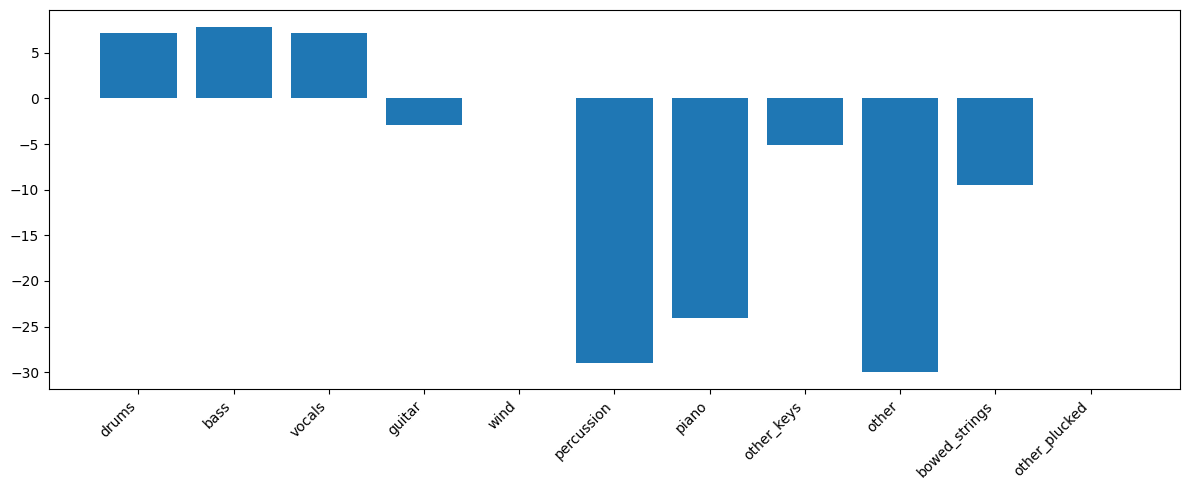

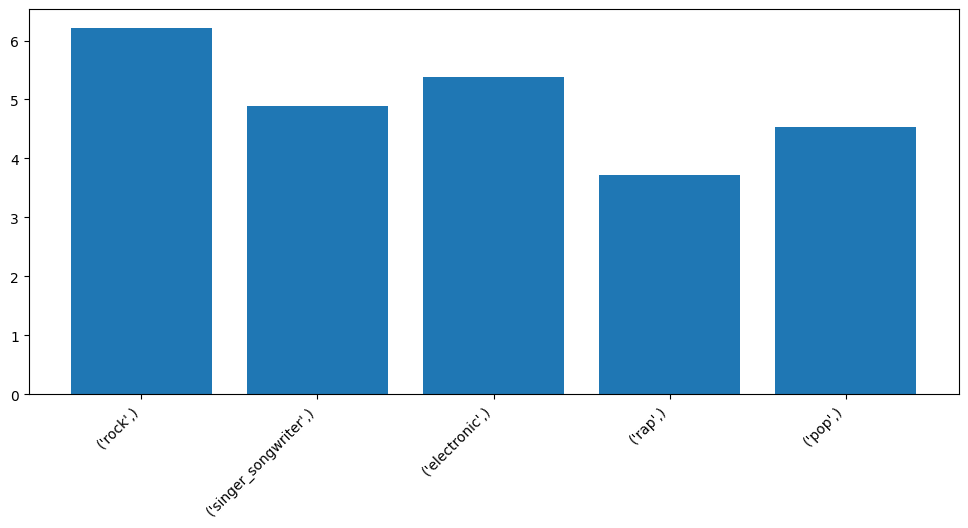

In [ ]:
# test the model
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import os # Import the os module

learning_rate = 2e-5
epochs = 1 # Increased epochs
best_acc = 0.0
plots = { "train_loss": [], "train_sisdr": [],
  "genre": {}, "instruments": {} }
plots["instruments"] = {i:[0,0] for i in all_instruments}

# get better dataloaders
# Check accuracy on validation data
small_test_data = test_data# Subset(test_data, indices=list(range(0, 11)))
# loader grabs 1 track at a time
small_test_loader = DataLoader(small_test_data, batch_size=1, shuffle=False)

# initialize the Finetuner
SeparationModel = Fine_al_tuner()
SeparationModel.to(device) # move to gpu
# initialize the optimizer
optimizer = optim.Adam(SeparationModel.parameters(), lr=learning_rate, betas=(0.9, 0.999))

# Ensure the directory for saving weights exists
output_dir = os.path.dirname("/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth")
if output_dir:
    os.makedirs(output_dir, exist_ok=True)

# load in the finetuner's weigths
if os.path.exists("/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth"):
  print("Loading weights from long path")
  SeparationModel.finetuner.load_state_dict(torch.load("/content/drive/MyDrive/cse493g1/final/finetuner_weights.pth"))
else:
  print("No previous weights, starting again")

# no learning
test_loss, test_sisdr = train_val(SeparationModel, small_test_loader, None, plots, epoch, epochs)
# save the best accuracy
if test_sisdr > best_acc:
  best_acc = test_sisdr

print("best_acc", best_acc)

# format the genre and instrument scores back to averages
for genre in plots["genre"]:
  if type(plots["genre"][genre]) == list:
    plots["genre"][genre] = plots["genre"][genre][0] / plots["genre"][genre][1]

for inst in plots["instruments"]:
  if plots["instruments"][inst][1] == 0:
    plots["instruments"][inst] = 0
  else:
    plots["instruments"][inst] = plots["instruments"][inst][0] / plots["instruments"][inst][1]

# plot the graphs
print(plots)
getInstrumentGraph(plots["instruments"])
getGenreGraph(plots["genre"])

# Conclusion
Waveform Sound Separation is a potentially viable avenue to explore, however it has many drawbacks that have likely led to it being a less-explored area. In particular, the audio files are so large and slow to process that training takes significantly longer than it would have taken to use a fixed size spectrogram. In general, since images are easier for the model to work with, there might to be some extra innovation on the waveform space for this sound separation approach to become more viable.

In addition, ours, like many models, needed to enforce a fixed-stem size in order to batch songs that could have different numbers of instrument in each. Essentially our model transitioned DEMUCS from a 4-stem model to an 11-stem model. More work needs to be done to explore how processing variable stem counts can be done efficiently.